# 1st Kr NEXT-100 data look

## Kr trigger without trigger

In [2]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

## Configuration

In [3]:
import re
import glob
from collections import namedtuple

import sys
pypaths= ("/Users/hernando/work/investigacion/NEXT/software/nextana",
         "/Users/hernando/work/investigacion/NEXT/software/hipy",
         "/Users/hernando/work/investigacion/NEXT/software/IC")
for ipypath in pypaths:
       sys.path.insert(0,ipypath)

In [4]:
import numpy             as np
import pandas            as pd
import tables            as tb
from   scipy             import stats
from   scipy             import optimize

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

plt.rcParams['image.cmap'] = 'rainbow'

In [5]:
from invisible_cities.io.dst_io import load_dst, load_dsts

In [6]:
import hipy.utils        as ut
import hipy.pltext       as pltext
import hipy.profile      as prof

import nana.kr.krana    as krana
import nana.kr.krmap    as krtool

#import nana.bclouds.bclouds      as bc
#import hipy.hfit         as hfit
from invisible_cities.io.dst_io import load_dst, load_dsts
#import invisible_cities.io.dst_io as dio

In [7]:
pltext.style()

import warnings
warnings.filterwarnings('ignore')

import time
print(' Last revision ', time.asctime())

 Last revision  Mon Feb 24 11:03:42 2025


## Import Data

In [8]:
path_data = '/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/' 
path_run  = '14862/sophronia'
#path_run = '/250107_4bar/data/kdst'
#path_run = '/250203_4bar'


from os import listdir

filenames = listdir(path_data + path_run)
filenames.sort()
print('number of files :', len(filenames))
print('fist files: ', filenames[0], filenames[-1])
filenames = [path_data + path_run + '/' + ifile for ifile in filenames]

number of files : 3
fist files:  ldc1.hdst ldc3


In [9]:
#kdst = load_dsts(filenames[:1000], "DST", "Events")
kdst = load_dst(filenames[0], "DST", "Events")

### Fidutial selection

In [10]:
print('size x ', np.min(kdst.X[kdst.X > -1000.]), np.max(kdst.X))
print('size y ', np.min(kdst.Y[kdst.Y > -1000.]), np.max(kdst.Y))
kdst = kdst.rename(columns = {'S2e' : 'energy', 'X' : 'x', 'Y' : 'y', 'Z' : 'dt', 'Zrms': 'dtrms',
                              'DT' : 'dtime', 'R' : 'r'})
print(list(kdst.columns))

size x  -479.2658287733307 484.98862133287315
size y  -474.5129637365553 480.4438046775829
['event', 'time', 's1_peak', 's2_peak', 'nS1', 'nS2', 'S1w', 'S1h', 'S1e', 'S1t', 'S2w', 'S2h', 'energy', 'S2q', 'S2t', 'qmax', 'Nsipm', 'dtime', 'dt', 'dtrms', 'x', 'y', 'r', 'Phi', 'Xrms', 'Yrms']


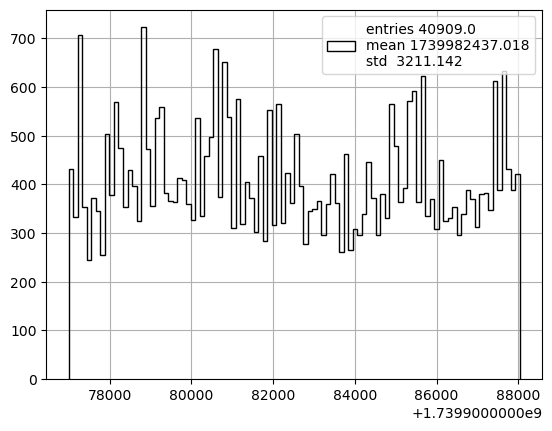

In [11]:
mkdst = kdst
pltext.hist(mkdst.time, 100);

## Study data

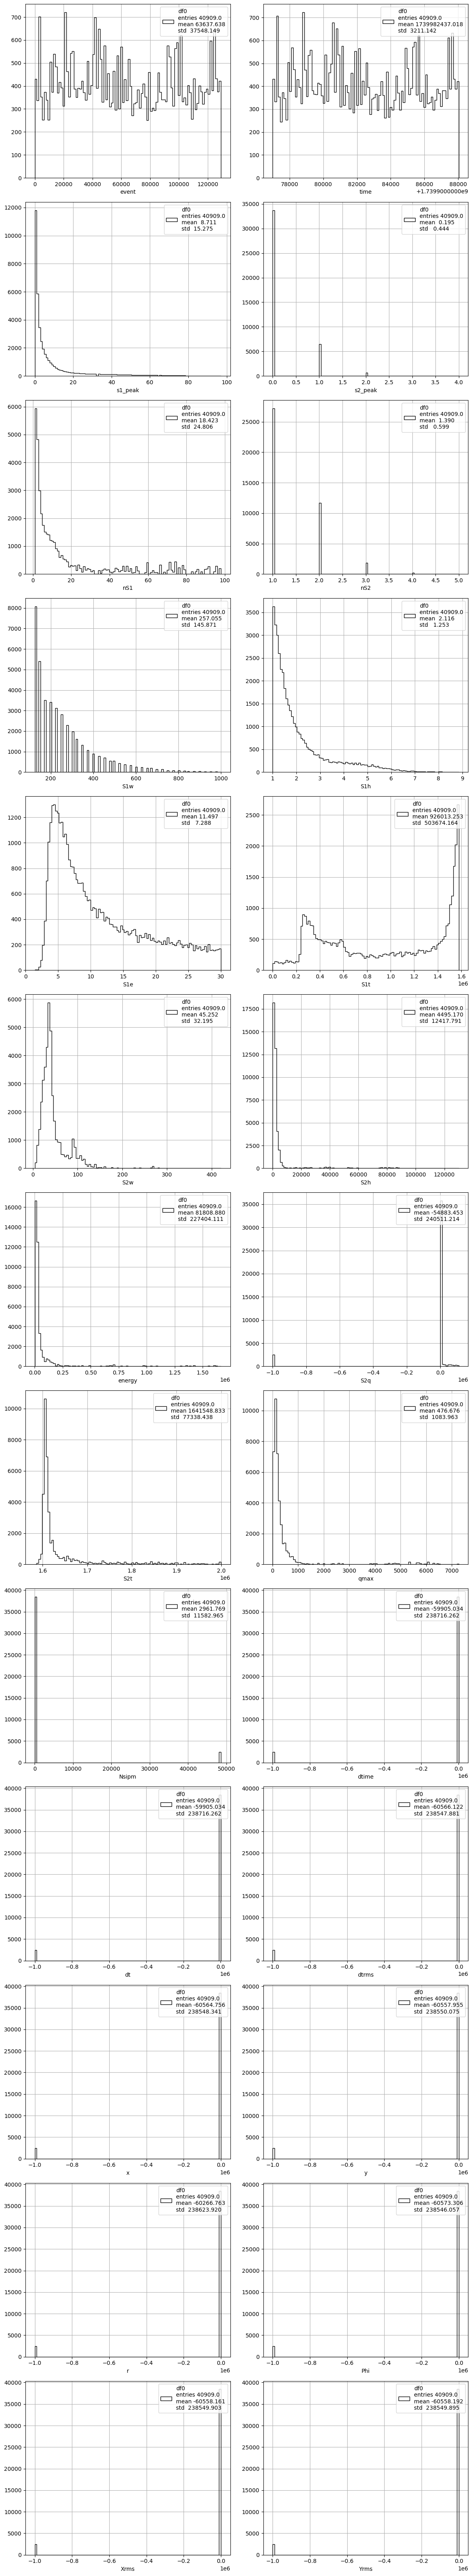

In [12]:
pltext.df_inspect(kdst)

## Selection

In [13]:
sels = {}
sels['1S2']      = mkdst.nS2 == 1
sels['onlyS2']   = mkdst.s1_peak == 0
sels['r']        = ut.in_range(mkdst.r  , (0., 500.))
sels['dtime']    = ut.in_range(mkdst.dtime , (0., 2000.))
sels['energy']   = ut.in_range(mkdst.energy, (0e3, 20e4))
sels['fidutial'] = (sels['r']) & (sels['dtime']) & (sels['energy'])

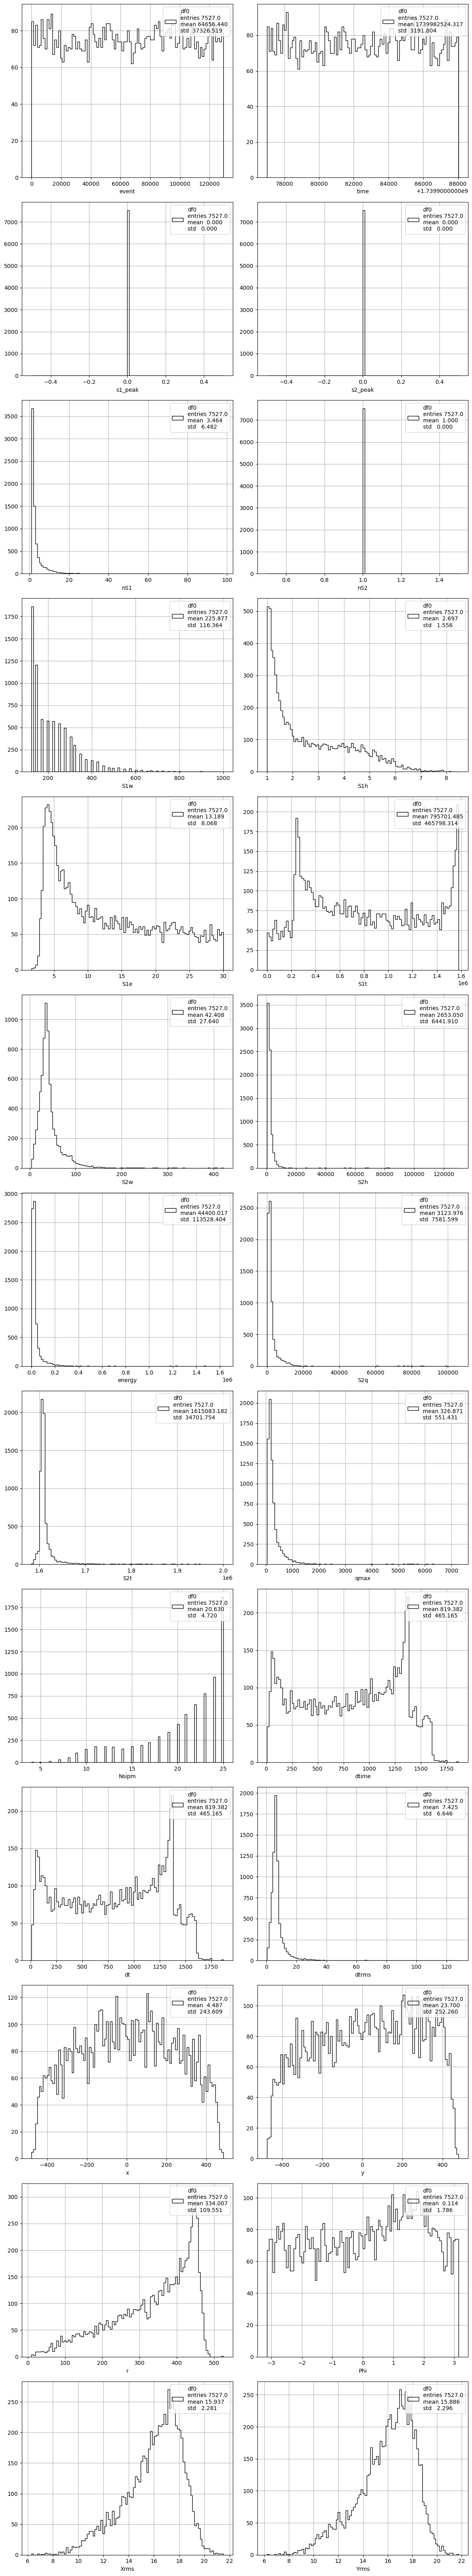

In [14]:
sel = (sels['1S2']) & (sels['dtime']) & (sels['onlyS2'])
rkdst = mkdst[sel]
pltext.df_inspect(rkdst)

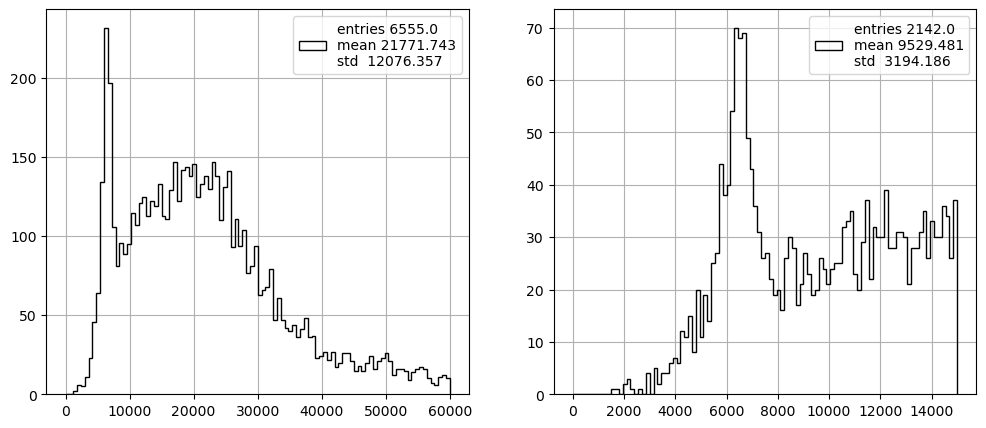

In [26]:
erangeS2 = (0, 6e4)
cd = pltext.canvas(2, 2)
cd(1)
esel = ut.in_range(rkdst.energy, erangeS2)
pltext.hist(rkdst[esel].energy, 100, range = erangeS2);
cd(2)
pltext.hist(rkdst[esel].energy, 100, range = (0, 15e3));

plt.scatter(rkdst[esel].S1e, rkdst[esel].energy, alpha = 0.05);

## Interpreting the S2

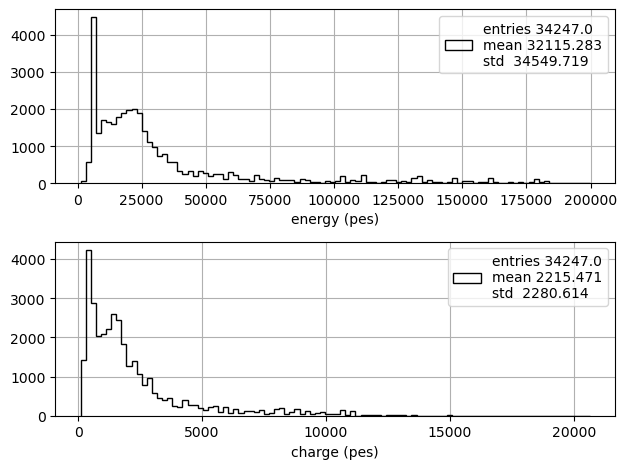

In [ ]:
sel = sels['fidutial']
plt.subplot(2, 1, 1)
pltext.hist(kdst[sel].energy, 100); plt.xlabel('energy (pes)')
plt.subplot(2, 1, 2)
pltext.hist(kdst[sel].S2q, 100); plt.xlabel('charge (pes)'); plt.tight_layout()

### Main distributions

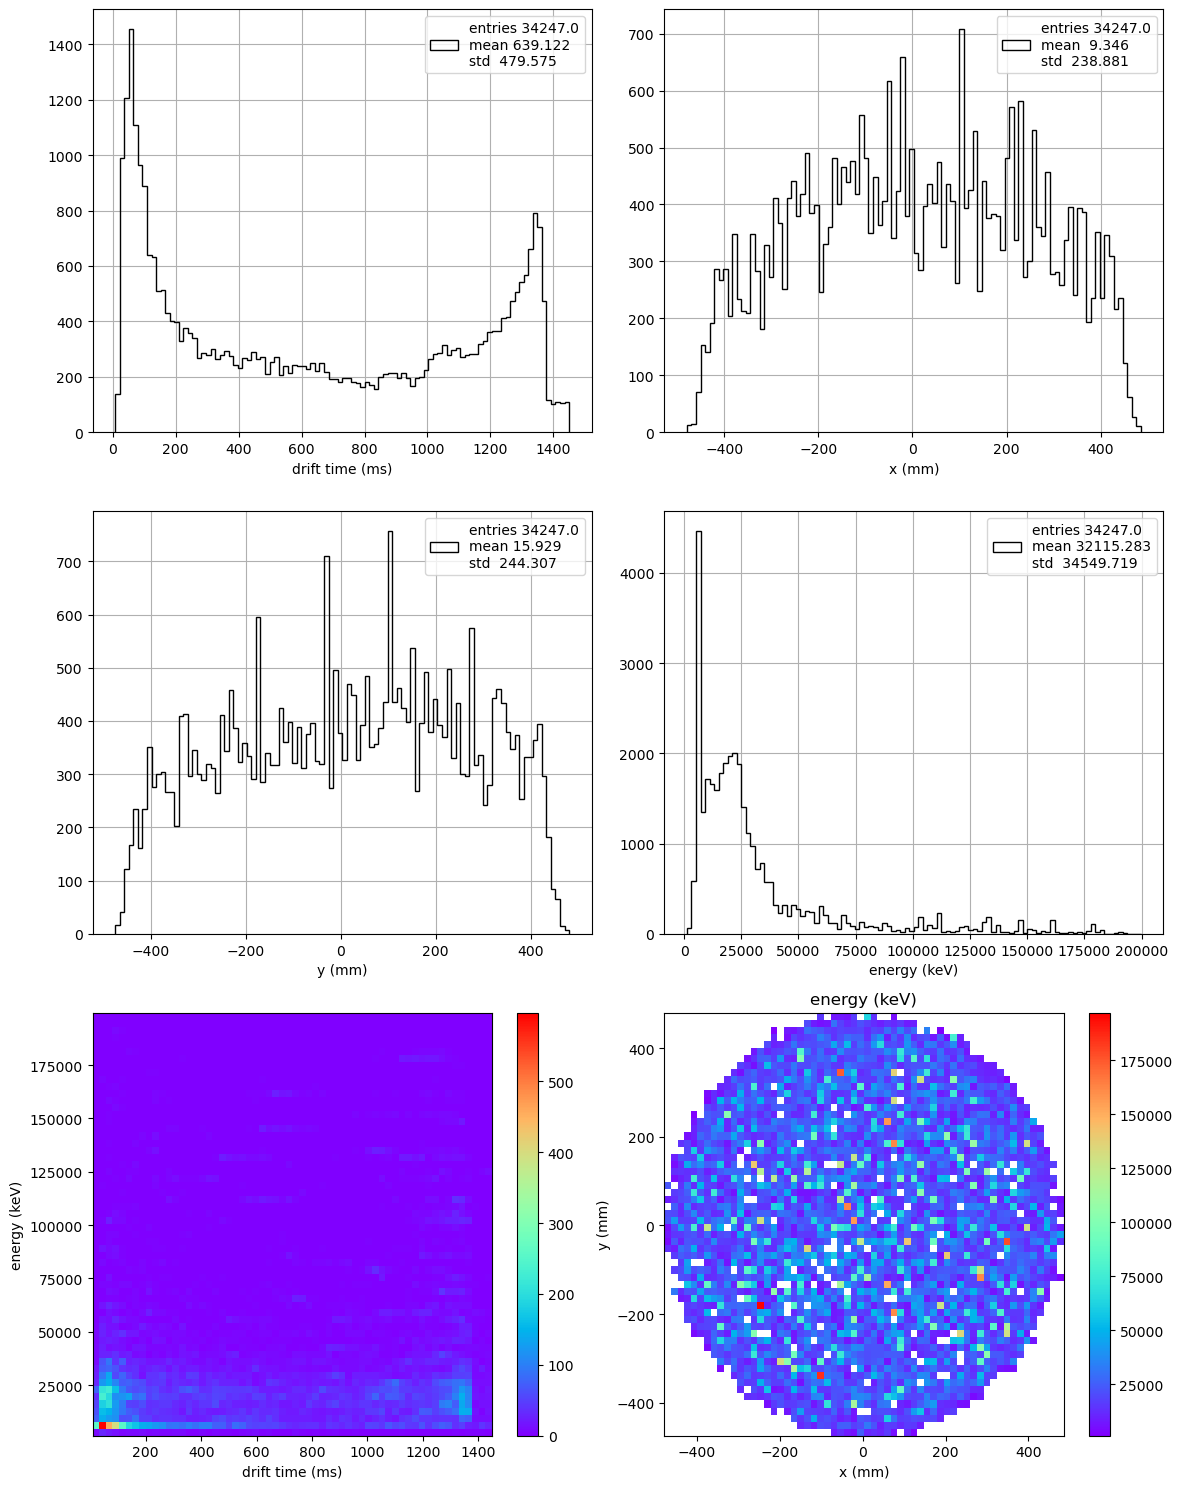

In [ ]:
sel = sels['fidutial']
krana.plot_data(mkdst[sel], 60)

In [ ]:
vdrift = np.max(mkdst[sel].z/mkdst[sel].dtime)
print('Drift velocity {:6.4f}'.format(vdrift))

Drift velocity 0.8700


## Kr map

In [ ]:
counts_min = 40
pitch      = 15.00
xmin       = -489.825
xbins      = np.arange(xmin, -xmin + pitch, pitch)
bins       = (xbins, xbins) 
print('number of bins ', len(xbins), ', range : ', xbins[0], ', ', xbins[-1])

number of bins  67 , range :  -489.825 ,  500.175


### clean map

In [ ]:
def clean_krmap(coors, dtime, energy, min_sigma = 0.9, dt0 = None, plot = True):
    sel     = np.ones(len(energy), bool)
    clean   = np.copy(sel)
    done    = False
    while (not done):
        icoors  = [coor[clean] for coor in coors]
        idtime  = dtime[clean]
        iene    = energy[clean]
        krmap, residuals   = krtool.krmap(icoors, idtime, iene,
                                         bins = bins, counts_min = counts_min, dt0 = dt0)
        done, usel = krtool.accept_residuals(residuals, range = (-5.,5.), 
                                            fun = 'gaus', nsigma = 4., min_sigma = min_sigma, plot = plot)
        clean[clean == True] = usel
    return krmap, clean

In [ ]:
sel    = sels['fidutial']
coors  = mkdst[sel].x, mkdst[sel].y
energy = mkdst[sel].energy
dtime  = mkdst[sel].dtime
counts_min = 60
bins   = (xbins, xbins) 

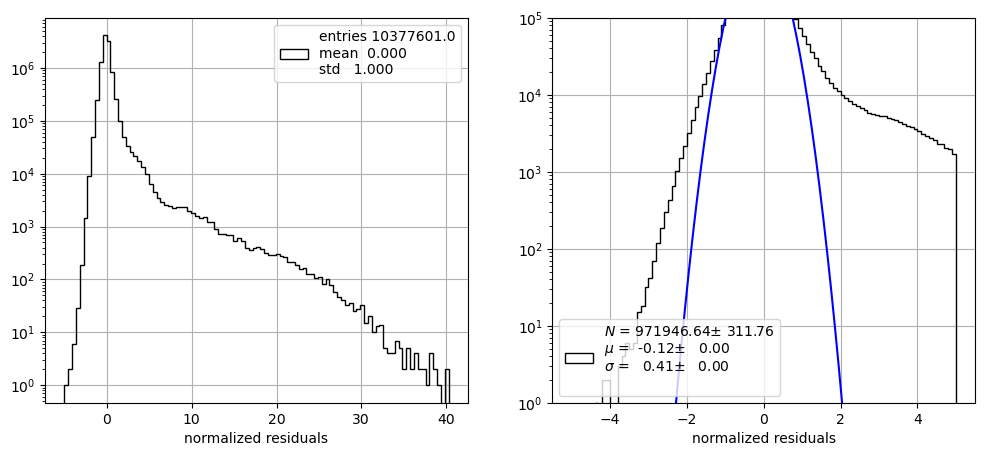

sigma 0.41 done  False  eff 97.43


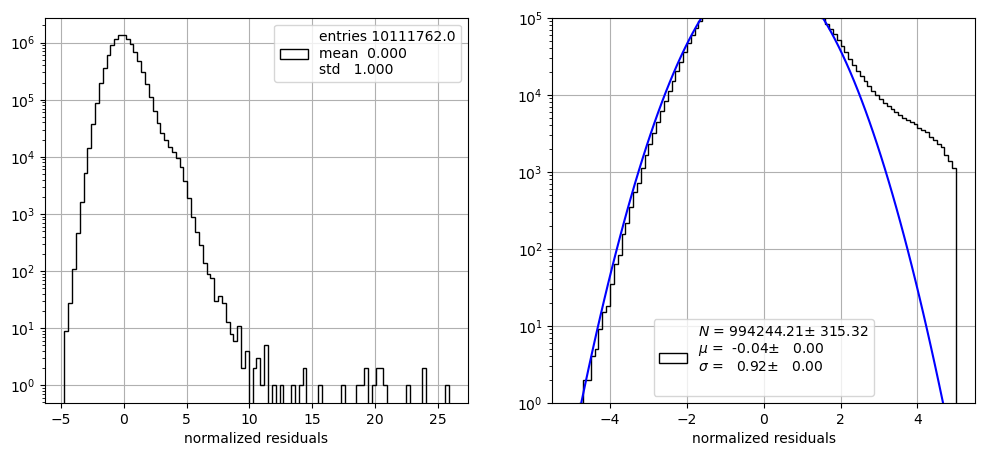

sigma 0.92 done  True  eff 100.00


In [ ]:
min_sigma = 0.92
krmap, usel = clean_krmap(coors, dtime, energy, min_sigma = min_sigma, dt0 = None)

In [ ]:
def krmap_set_lifetime(krmap):
    dedt, udedt = krmap.dedt, krmap.udedt
    eref, ueref = krmap.eref, krmap.ueref
    lt  = eref/dedt
    ult = np.sqrt((ueref/dedt)**2 + (lt * udedt/dedt)**2)
    return lt, ult


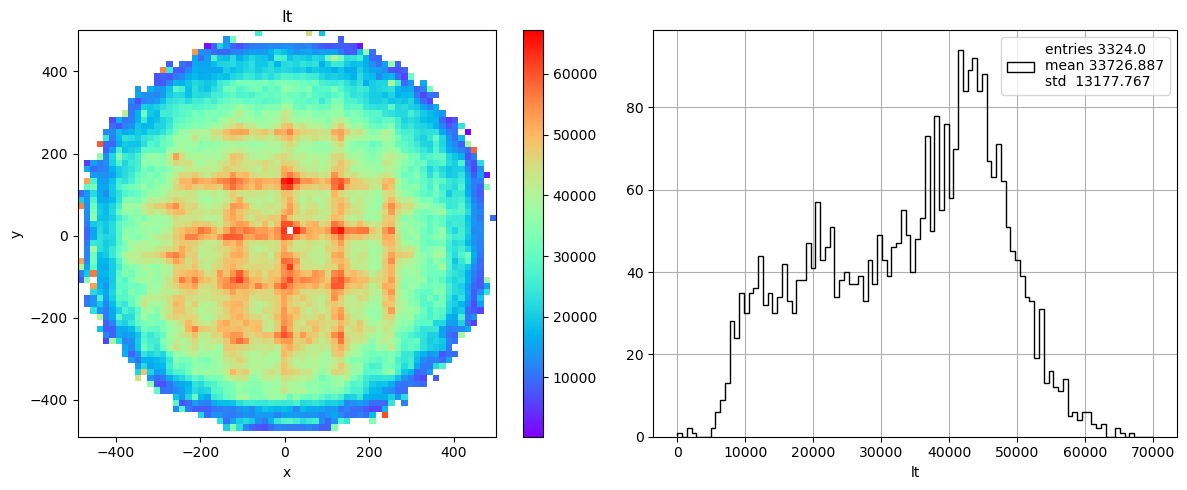

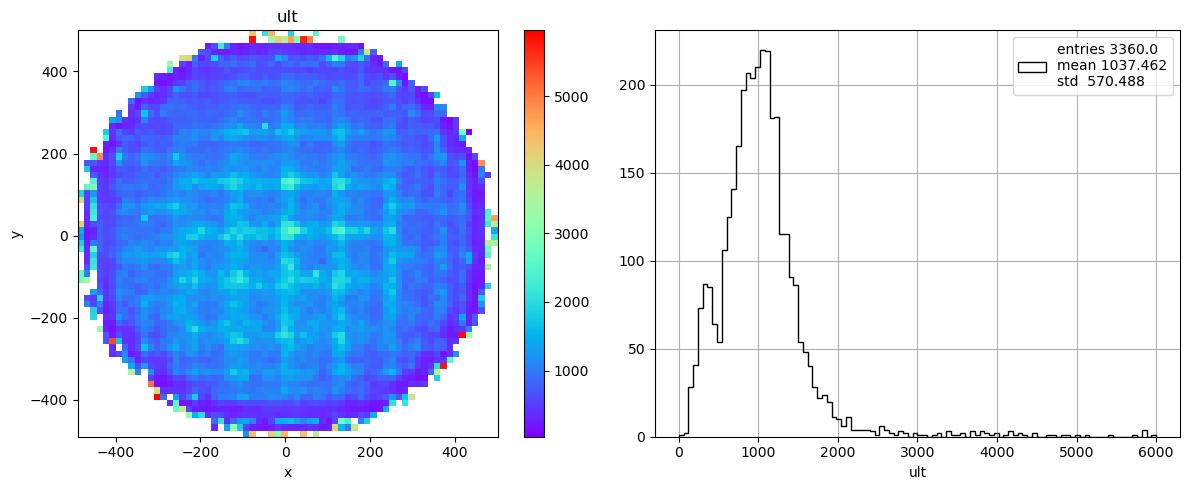

In [ ]:
lt, ult = krmap_set_lifetime(krmap)
krtool.plot_xyvar(lt   , krmap.bin_edges, 'lt'  , mask = krmap.success, range = (0, 7e4));
krtool.plot_xyvar(ult  , krmap.bin_edges, 'ult' , mask = krmap.success, range = (0, 6e3))


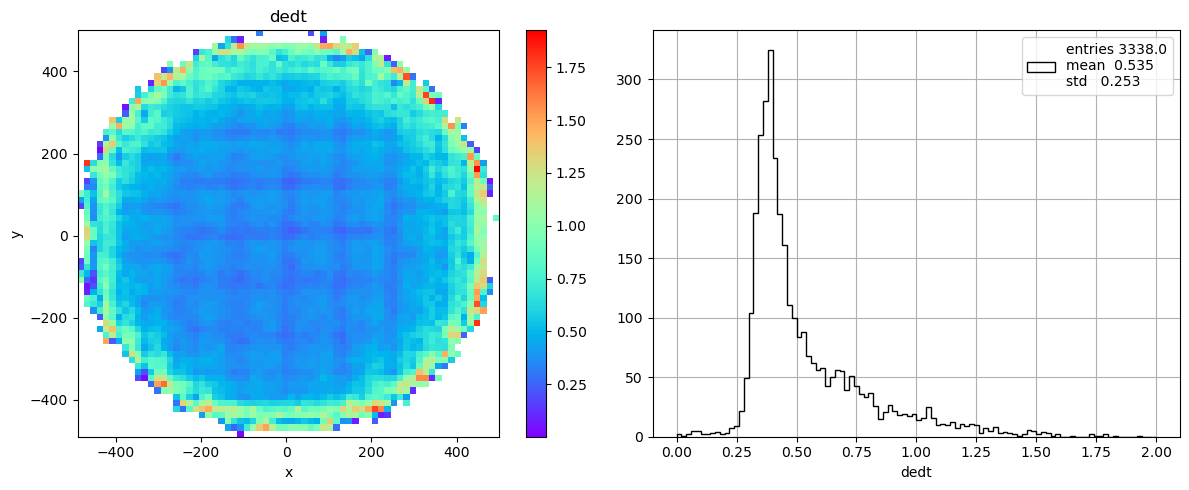

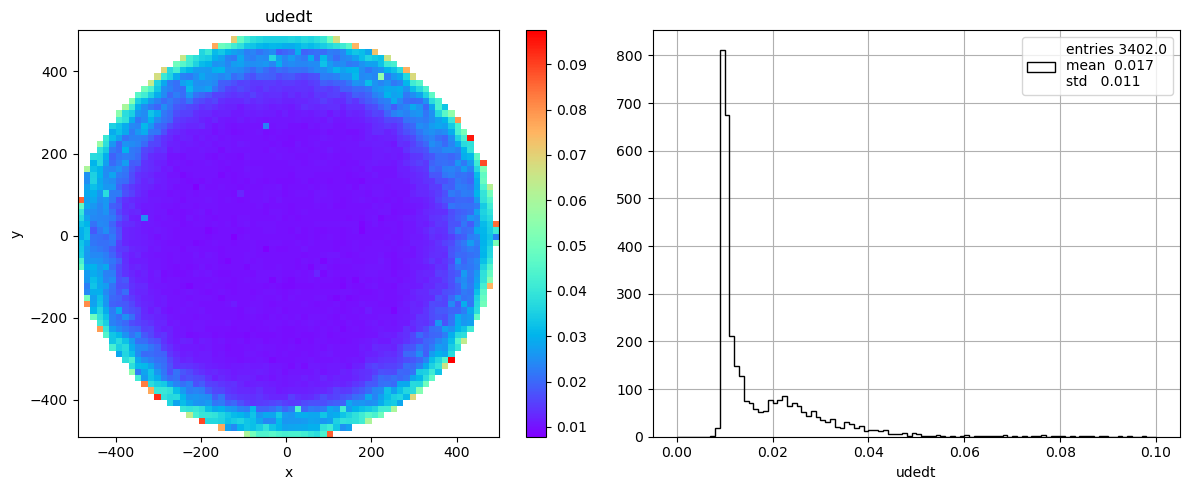

In [ ]:
lt, ult = krmap_set_lifetime(krmap)
krtool.plot_xyvar(krmap.dedt   , krmap.bin_edges, 'dedt'  , mask = krmap.success, range = (0, 2));
krtool.plot_xyvar(krmap.udedt  , krmap.bin_edges, 'udedt'  , mask = krmap.success, range = (0, 0.1))

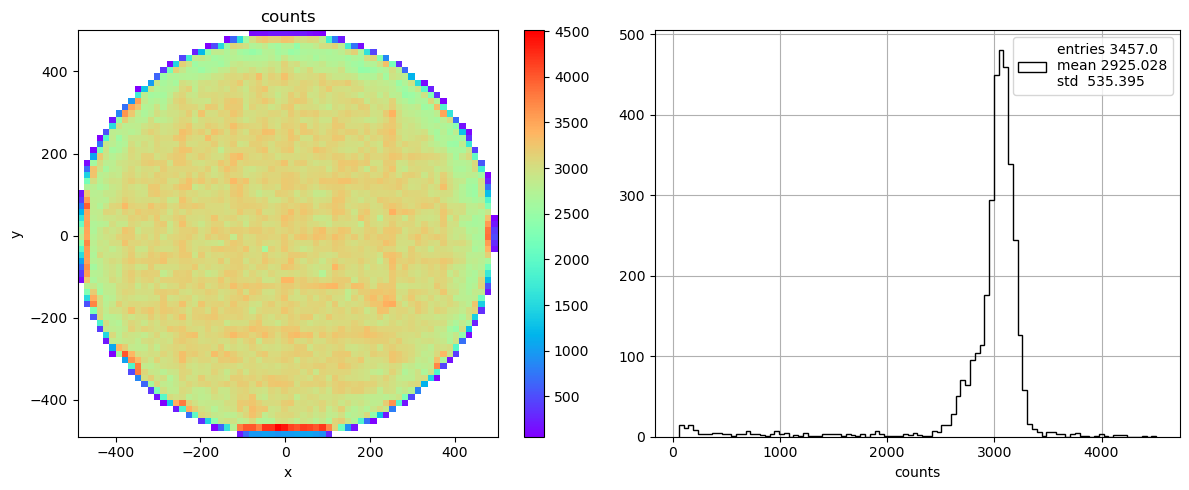

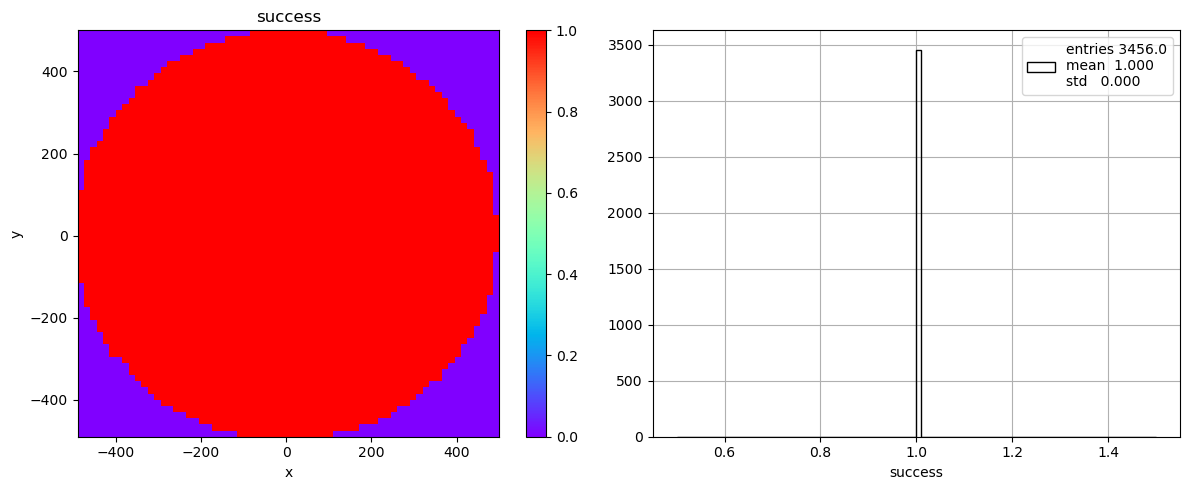

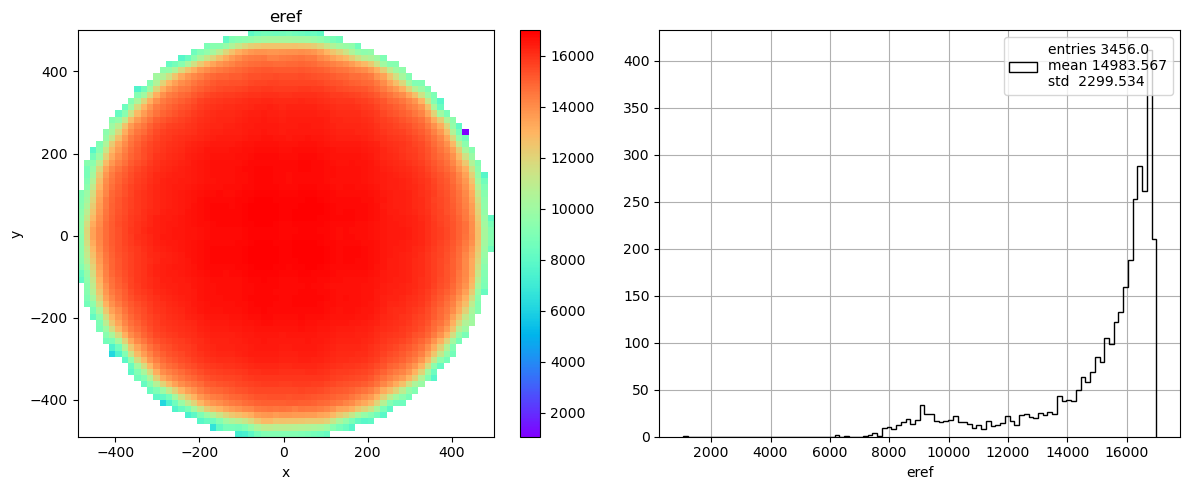

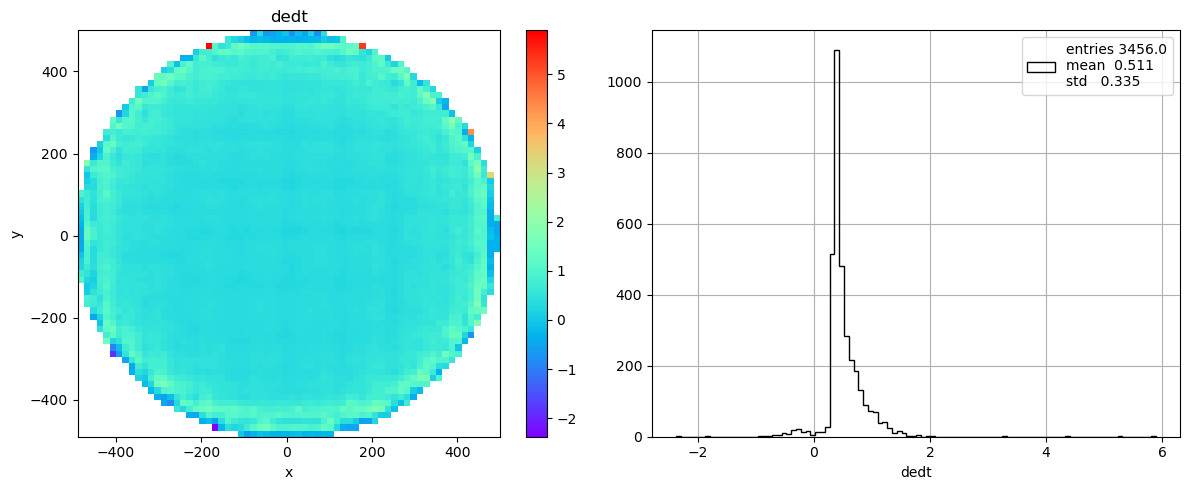

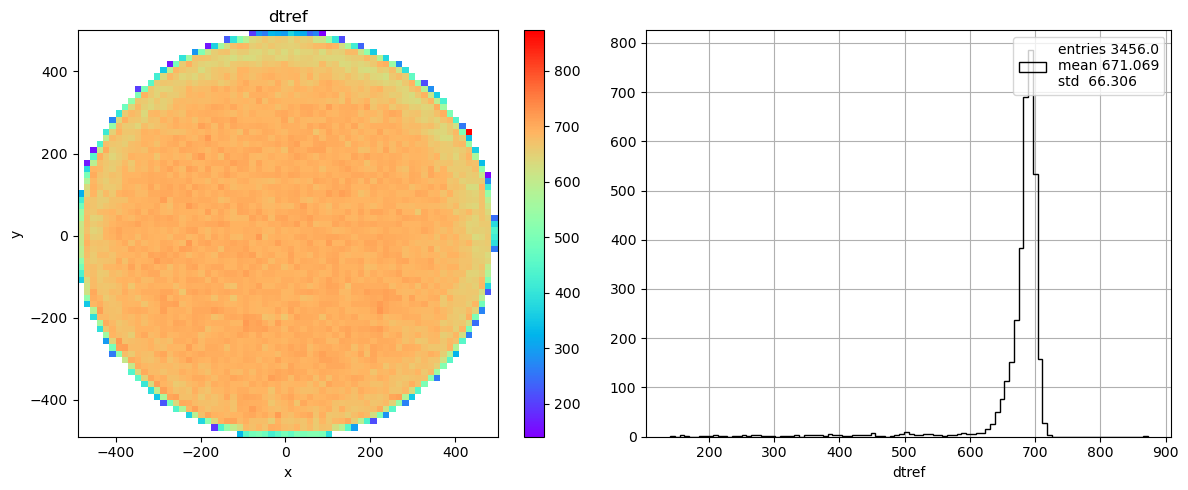

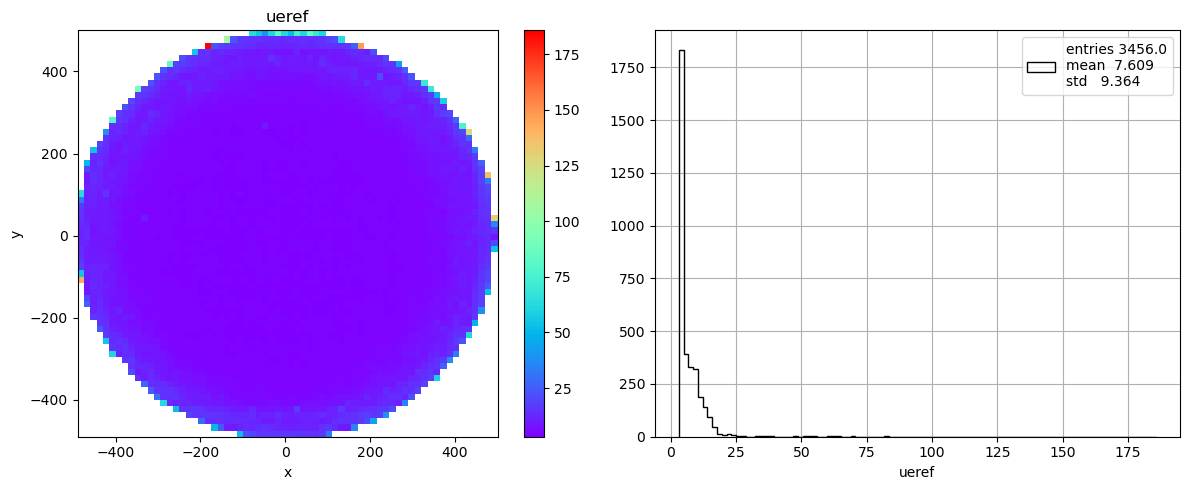

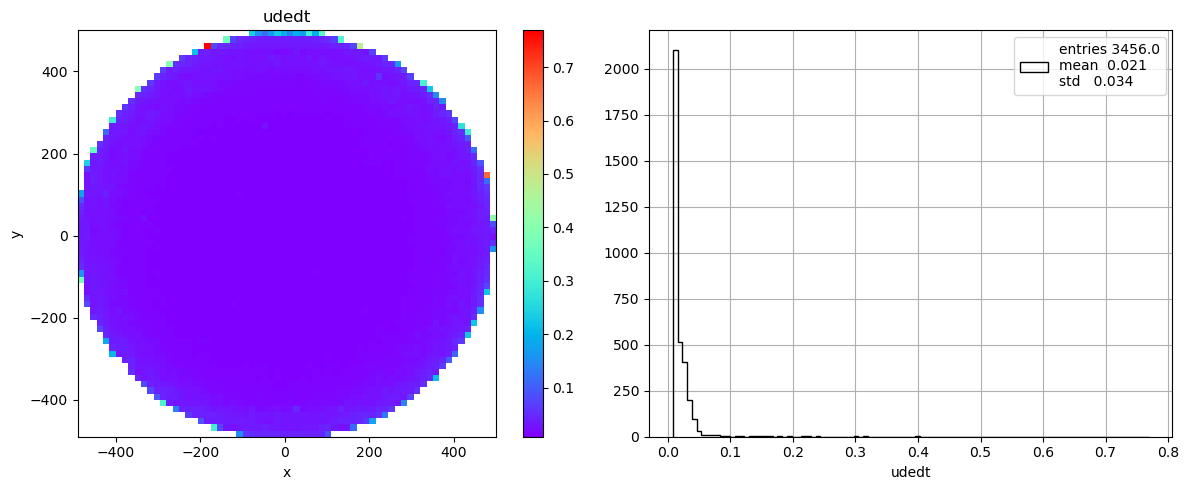

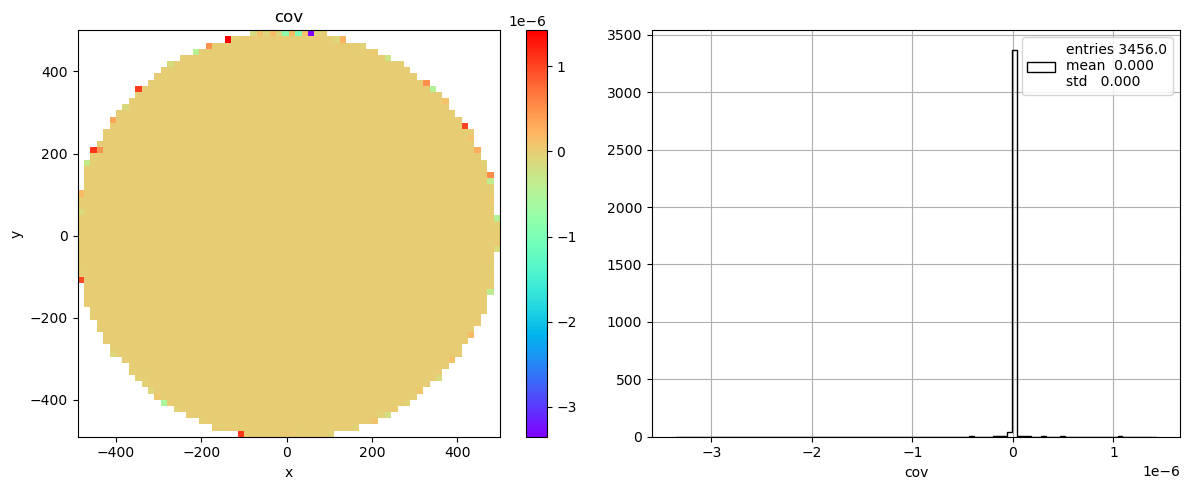

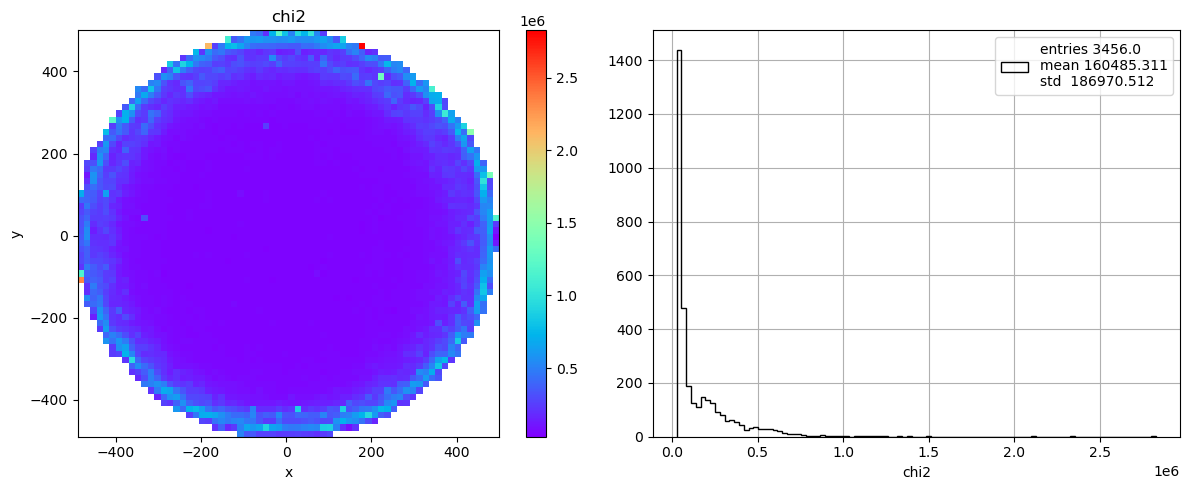

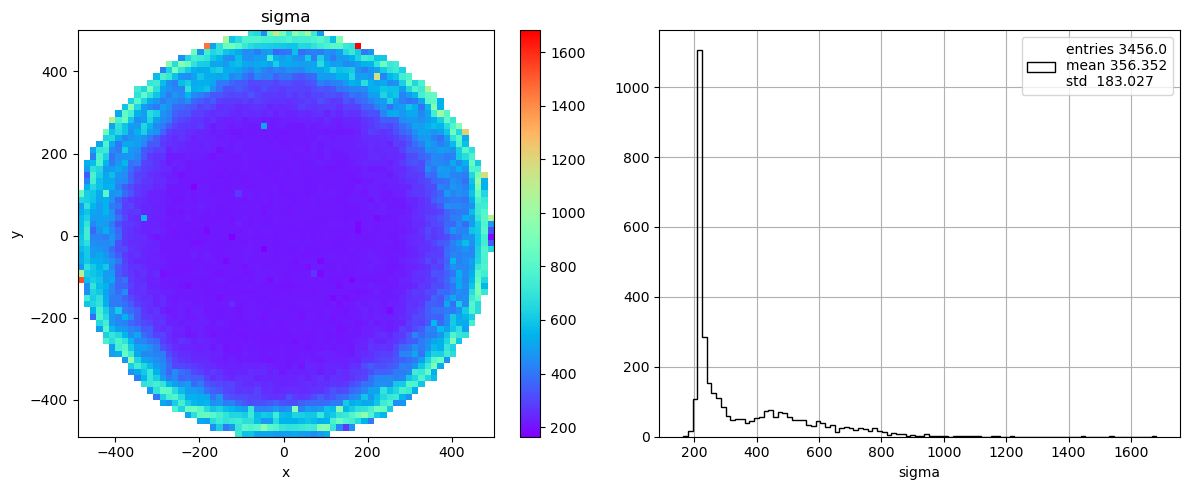

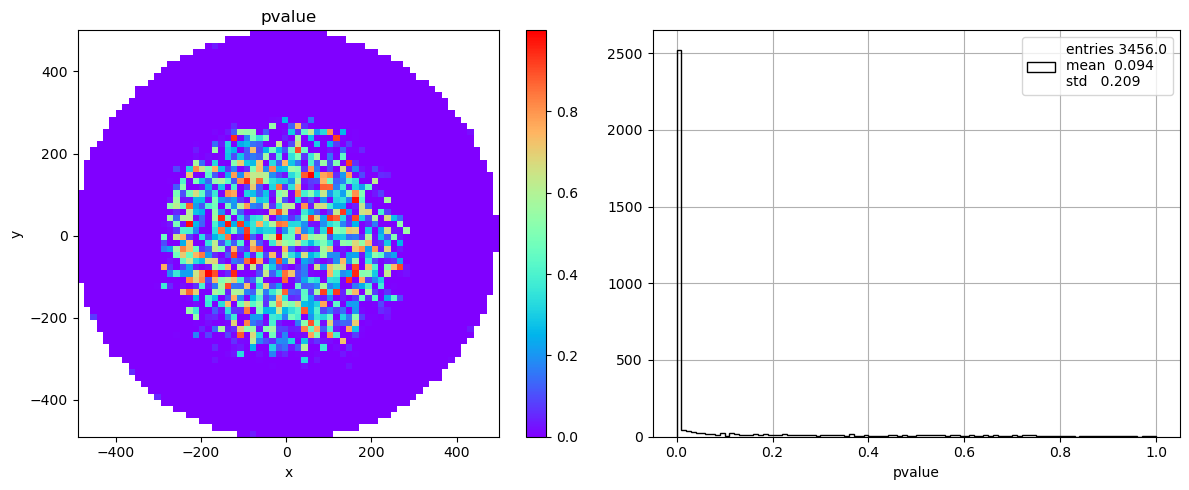

In [ ]:
krtool.plot_xyvar(krmap.counts , krmap.bin_edges, 'counts' , mask = krmap.counts > 0)
krtool.plot_xyvar(krmap.success, krmap.bin_edges, 'success', mask = krmap.success)
krtool.plot_xyvar(krmap.eref   , krmap.bin_edges, 'eref'   , mask = krmap.success)
krtool.plot_xyvar(krmap.dedt   , krmap.bin_edges, 'dedt'   , mask = krmap.success)
krtool.plot_xyvar(krmap.dtref  , krmap.bin_edges, 'dtref'  , mask = krmap.success)
krtool.plot_xyvar(krmap.ueref  , krmap.bin_edges, 'ueref'  , mask = krmap.success)
krtool.plot_xyvar(krmap.udedt  , krmap.bin_edges, 'udedt'  , mask = krmap.success)
krtool.plot_xyvar(krmap.cov    , krmap.bin_edges, 'cov'    , mask = krmap.success)
krtool.plot_xyvar(krmap.chi2   , krmap.bin_edges, 'chi2'   , mask = krmap.success)
krtool.plot_xyvar(krmap.sigma  , krmap.bin_edges, 'sigma'  , mask = krmap.success)
krtool.plot_xyvar(krmap.pvalue , krmap.bin_edges, 'pvalue' , mask = krmap.success)

## Correction

In [ ]:
corr_energy = krtool.krmap_scale(coors, dtime, energy, krmap, scale = 41.5)

 Resolution   3.95 % FWHM


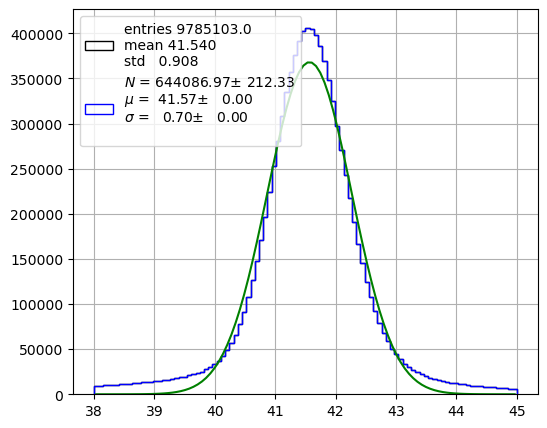

In [ ]:
xsel = ~np.isnan(corr_energy)
nbins, erange = 100, (38., 45)
pltext.canvas(1, 1);
pltext.hist(corr_energy[xsel], nbins, erange);
cc = pltext.hfit(corr_energy[xsel], nbins, range = erange, fun = 'gaus');
pars = cc[3]
resolution = 235.5 * pars[2]/pars[1]
print(' Resolution {:6.2f} % FWHM'.format(resolution))

In [ ]:
mu, umu = 41.57, 0.76
eres     = umu/mu * 235.
eres_qbb = eres * np.sqrt(0.041/2.458)
print('energy resolution FWHM Kr  :', eres)
print('emergy resolution FWHM Qbb :', eres_qbb)

energy resolution FWHM Kr  : 4.2963675727688235
emergy resolution FWHM Qbb : 0.5548842771963416


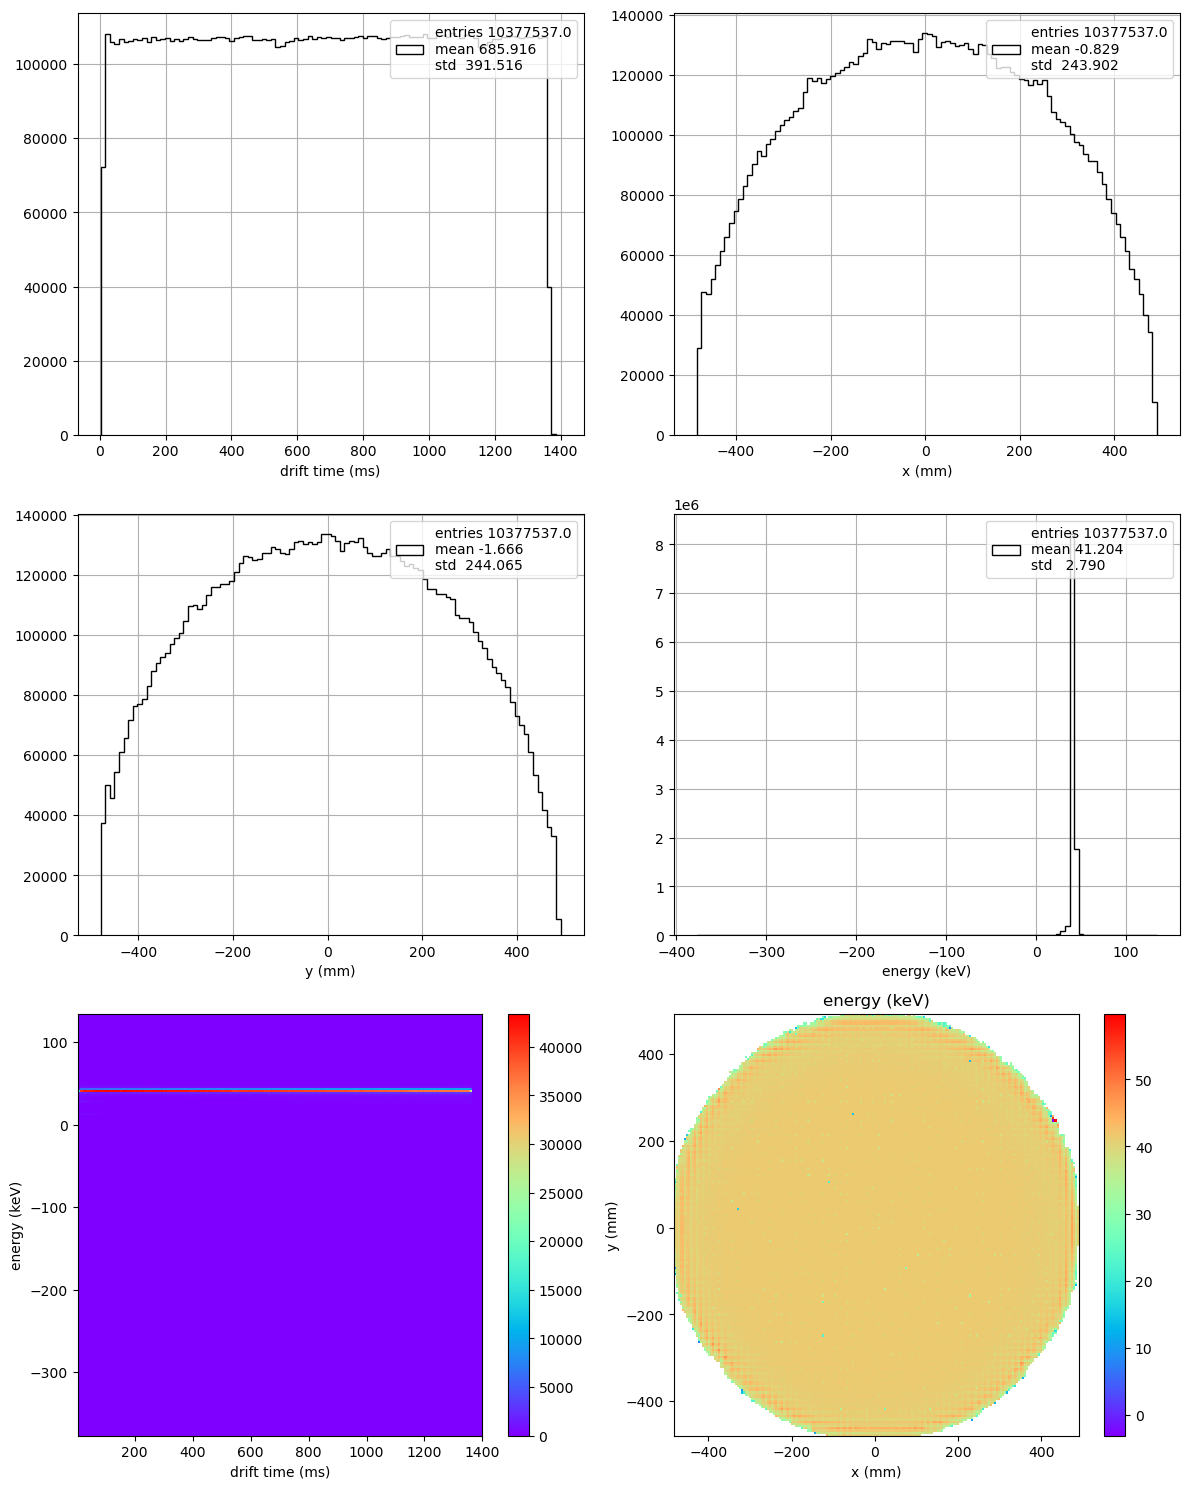

In [ ]:
xsel = ~np.isnan(corr_energy)
df = {'x': coors[0][xsel], 'y' : coors[1][xsel], 'dtime': dtime[xsel], 'energy' : corr_energy[xsel]}
df = pd.DataFrame(df)
krana.plot_data(df, bins = 200)
#plt.subplot(3, 2, 5)
#plt.ylim((25, 45));

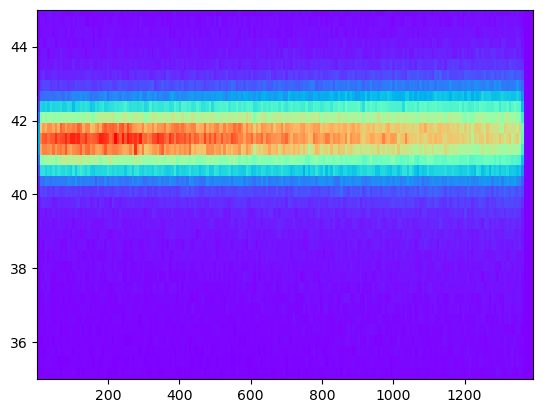

In [ ]:
plt.hist2d(df.dtime, df.energy, 200);
plt.ylim((35, 45));

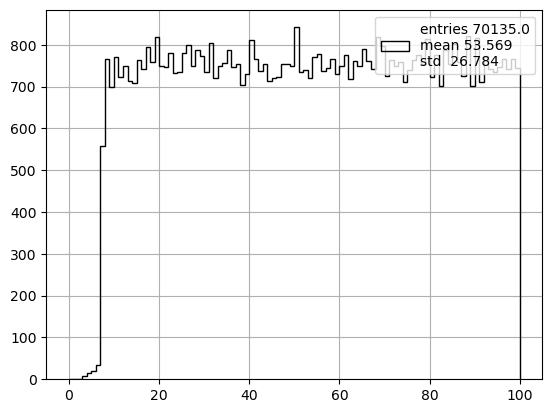

In [ ]:
plt.p

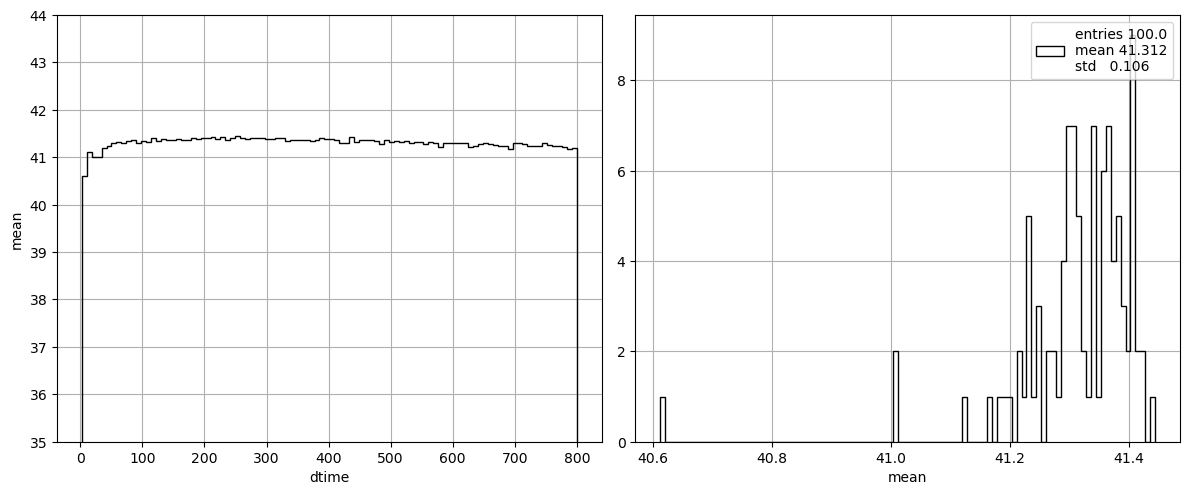

In [ ]:
sel = df.dtime < 800
zprof, _  = prof.profile((df.dtime[sel],), df.energy[sel], nbins)
prof.plot_profile(zprof, nbins = nbins, stats = ('mean',), coornames = ('dtime',))
plt.subplot(1, 2, 1);
plt.ylim((35, 44));

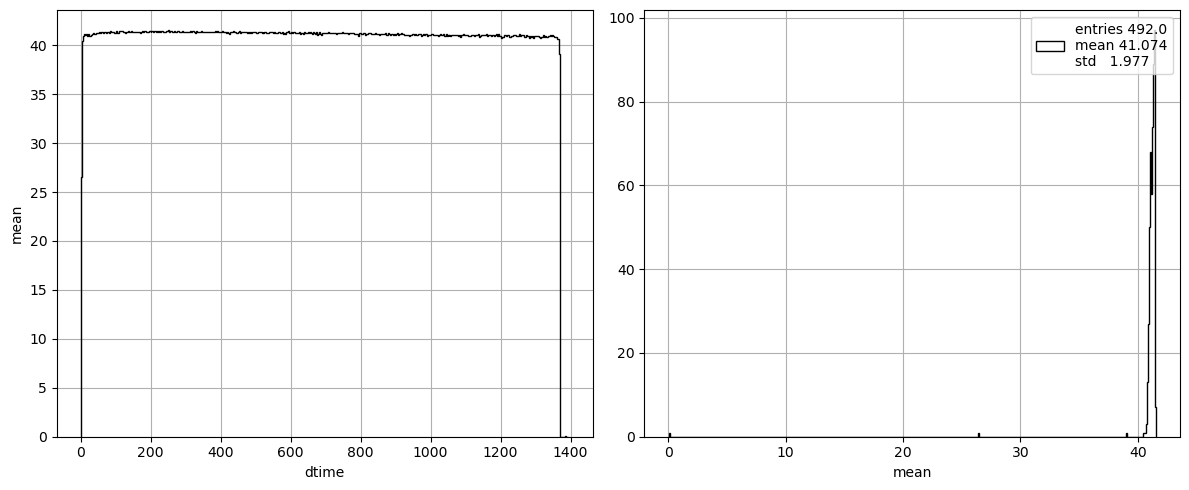

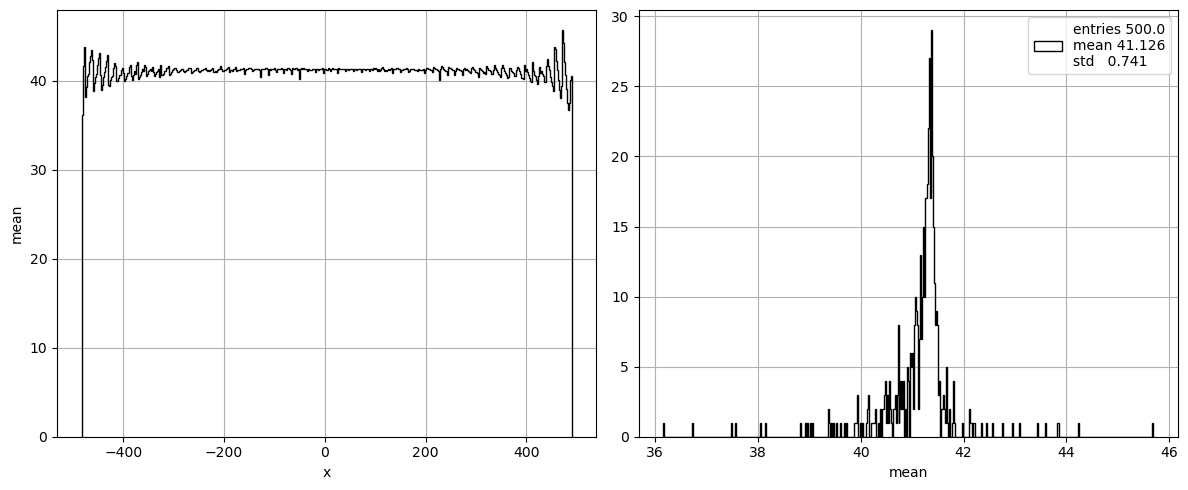

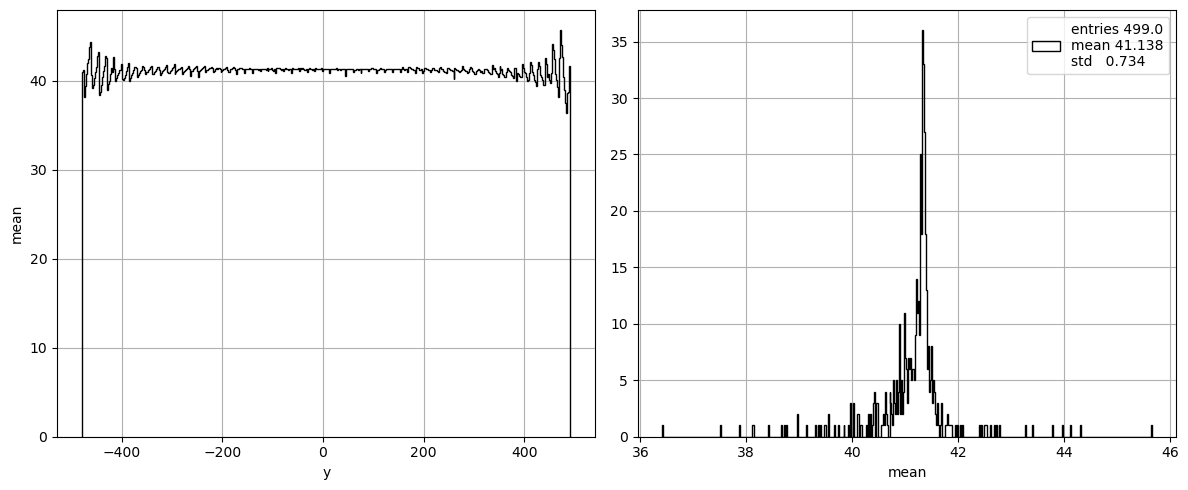

In [ ]:
krtool.plot_xydt_energy_profiles(df, nbins = 500)


## Charge